# Model 3 Neural Network



## 1 - Packages

In [92]:
import ipympl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import * 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from utils import load_split, FEATURE_COLUMNS
from pathlib import Path
from autils import *
from lab_utils_softmax import plt_softmax

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

np.set_printoptions(precision=2)

print("All packages loaded successfully.")

All packages loaded successfully.


## 2 - Loading data

In [88]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 41)
The shape of y is: (100778,)


## 3 - Normalising data

In [89]:
#Scale input data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Integers to one-hot vectors
y_train_multi = to_categorical(y_train, num_classes=40)
y_val_multi   = to_categorical(y_val, num_classes=40)
y_test_multi = to_categorical(y_test, num_classes=40)

# Map Class 16 to 0, all other to 1
y_train_bin = np.where(y_train == 16, 0, 1)
y_val_bin   = np.where(y_val == 16, 0, 1)
y_test_bin = np.where(y_test == 16, 0, 1)

## 4 - Multi-classification

### 3.1 - Training model 3v1: Neural network with 20 training cycles and no regularisation 

In [90]:
input_shape = (X_train_scaled.shape[1],) 
num_classes = 40
print("--- Building Model 3v1 ---")
# Build Model 1 (Neural network with 20 training cycles, no early stopping)
model_3v1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3v1.compile(optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=['accuracy'])

# Train
print("Training  Model 3v1...")
history_3v1 = model_3v1.fit(
    X_train_scaled, y_train_multi,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_multi)
)

--- Building Model 3v1 ---
Training  Model 3v1...
Epoch 1/20


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - accuracy: 0.9525 - loss: 0.2048 - val_accuracy: 0.9885 - val_loss: 0.0458
Epoch 2/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9829 - loss: 0.0616 - val_accuracy: 0.9896 - val_loss: 0.0366
Epoch 3/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9857 - loss: 0.0502 - val_accuracy: 0.9910 - val_loss: 0.0299
Epoch 4/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9877 - loss: 0.0429 - val_accuracy: 0.9913 - val_loss: 0.0295
Epoch 5/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9888 - loss: 0.0382 - val_accuracy: 0.9921 - val_loss: 0.0257
Epoch 6/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9894 - loss: 0.0356 - val_accuracy: 0.9918 - val_loss: 0.0266
Epoch 7/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9901 - loss: 0.0328 - val_accuracy: 0.9917 - val_loss: 0.0258
Epoch 8/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9910 - loss: 0.0310 - val_accura

### 3.2 - Prediction and accuracy Model 3v1

In [ ]:
test_loss, test_acc = model_3v1.evaluate(X_test_scaled, y_test_multi, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

y_pred_3v1_probs = model_3v1.predict(X_test_scaled)

y_pred_3v1 = np.argmax(y_pred_3v1_probs, axis=1)
y_true_integers = np.argmax(y_test_multi, axis=1)

print("--- Classification Report ---")
report = classification_report(y_true_integers, y_pred_3v1, output_dict=True)
print(classification_report(y_true_integers, y_pred_3v1))

705/705 - 1s - 1ms/step - accuracy: 0.7121 - loss: 11.3776

Test Accuracy: 71.21%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       1.00      0.94      0.97       359
           2       0.73      0.40      0.52        20
           3       0.00      0.00      0.00         3
           4       0.84      0.03      0.05      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.77      0.98      0.86       141
           8       0.70      1.00      0.82         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.92      1.00   

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

### 3.3 - Training model 3v2: Neural network with L1 regularisation with early stopping mechanism

In [ ]:
print("--- Building Model 3v2 (L1 Regularized) ---")

model_3v2 = Sequential([
    Dense(128, activation='relu', 
                 input_shape=input_shape,
                 kernel_regularizer=tf.keras.regularizers.l1(0.001)), 
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3v2.compile(optimizer='adam', 
                loss='categorical_crossentropy', 
                metrics=['accuracy'])

print("Starting training...")
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history_3v2 = model_3v2.fit(
    X_train_scaled, y_train_multi,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_scaled, y_val_multi),
    callbacks=[early_stopping],
    verbose=1
)


--- Building Model 3v2 (L1 Regularized) ---
Starting training...
Epoch 1/50


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9481 - loss: 0.3993 - val_accuracy: 0.9836 - val_loss: 0.1507
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9768 - loss: 0.1565 - val_accuracy: 0.9855 - val_loss: 0.1181
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9795 - loss: 0.1340 - val_accuracy: 0.9886 - val_loss: 0.1026
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9816 - loss: 0.1196 - val_accuracy: 0.9883 - val_loss: 0.0974
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9825 - loss: 0.1119 - val_accuracy: 0.9873 - val_loss: 0.0898
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9828 - loss: 0.1087 - val_accuracy: 0.9871 - val_loss: 0.0924
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9841 - loss: 0.1028 - val_accuracy: 0.9866 - val_loss: 0.0854
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9833 - loss: 0.1012 - val_accurac

### 3.4 - Prediction and accuracy L1 regularized model 

In [98]:
test_loss, test_acc = model_3v2.evaluate(X_test_scaled, y_test_multi, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

y_pred_3v2_probs = model_3v2.predict(X_test_scaled)

y_pred_3v2 = np.argmax(y_pred_3v2_probs, axis=1)
y_true_integers = np.argmax(y_test_multi, axis=1)

print("--- Classification Report ---")
report = classification_report(y_true_integers, y_pred_3v2, output_dict=True)
print(classification_report(y_true_integers, y_pred_3v2))

705/705 - 1s - 1ms/step - accuracy: 0.7112 - loss: 4.4266

Test Accuracy: 71.12%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.48      0.98      0.65       359
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00         3
           4       0.91      0.02      0.03      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.87      0.97      0.92       141
           8       0.00      0.00      0.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.92      0.99  

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

### 3.5 - Accuracy and loss comparison of both multi-classclassification models over epochs

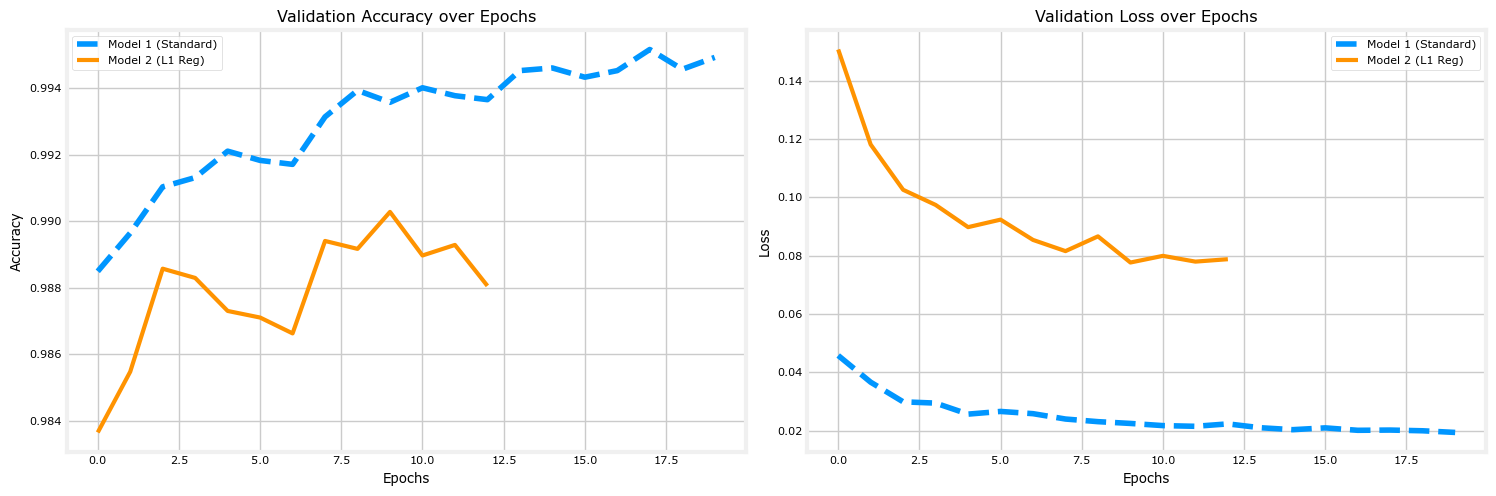

--- Final Project Results ---
          Metric Model 3v1 (Standard) Model 3v2 (L1 Regularized)
0  Test Accuracy               71.12%                     70.91%
1  Features Used       All 41 (Dense)   All 41 (Sparse/Filtered)


In [101]:
plt.close('all') 
# Create a clean figure with two subplots (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Validation Accuracy Comparison
ax1.plot(history_3v1.history['val_accuracy'], label='Model 1 (Standard)', linestyle='--')
ax1.plot(history_3v2.history['val_accuracy'], label='Model 2 (L1 Reg)', linewidth=3)
ax1.set_title('Validation Accuracy over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Comparison
ax2.plot(history_3v1.history['val_loss'], label='Model 1 (Standard)', linestyle='--')
ax2.plot(history_3v2.history['val_loss'], label='Model 2 (L1 Reg)', linewidth=3)
ax2.set_title('Validation Loss over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout() 
plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 3v1 (Standard)": [f"{test_acc*100:.2f}%", "All 41 (Dense)"],
    "Model 3v2 (L1 Regularized)": [f"{acc_2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)

## 5 - Binary classification

### 5.1 Converting multiclass to binary

In [78]:
y_binary = np.where(y_train == 16, 0, 1)

# Check the distribution
print("Class counts:")
print(pd.Series(y_binary).value_counts())
# You should now see only 0s and 1s

Class counts:
0    53874
1    46904
Name: count, dtype: int64


### 5.2 - Normalising data